#### Importing Important Library

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
# import the dataset
df = pd.read_csv("transactions_test.csv")

#### About the Dataset

In [3]:
df.head()

,transaction_id,transaction_time,customer_id,merchant_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,...,device_type,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,post_auth_risk_score
0,305461,2023-10-01 00:02:41.559131982,11453,7397,1417,4,2,7549.746993,0.056340,1783.564199,...,mobile,0,0.417366,1,2,0,54.226534,1531.905966,0,0.358507
1,341279,2023-10-01 00:06:25.507380194,28021,97,830,2,2,2766.322082,0.736960,7038.755549,...,mobile,0,0.272247,1,3,1,60.728405,6946.544813,0,0.065886
2,344364,2023-10-01 00:07:50.846454903,2269,2796,1651,2,3,3988.151593,0.454618,663.057016,...,mobile,0,0.446442,3,3,0,102.171038,530.118629,0,0.026225
3,84227,2023-10-01 00:17:11.834872052,32373,787,1207,1,2,5472.122178,0.417973,1665.509484,...,desktop,0,0.308703,2,3,0,10.146806,1483.105412,0,0.201940
4,187825,2023-10-01 00:19:50.841780964,13548,4439,1926,5,2,1758.784635,0.535169,1524.306346,...,mobile,1,0.305401,2,1,1,18.328551,1465.680191,0,0.234395


In [4]:
print(df.shape)
print(df.info())

(99887, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99887 entries, 0 to 99886
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   transaction_id                   99887 non-null  int64  
 1   transaction_time                 99887 non-null  object 
 2   customer_id                      99887 non-null  int64  
 3   merchant_id                      99887 non-null  int64  
 4   account_age_days                 99887 non-null  int64  
 5   credit_score_band                99887 non-null  int64  
 6   kyc_level                        99887 non-null  int64  
 7   avg_monthly_spend                99887 non-null  float64
 8   merchant_risk_score              99887 non-null  float64
 9   transaction_amount               99887 non-null  float64
 10  payment_channel                  99887 non-null  object 
 11  device_type                      99887 non-null  object 
 12  is_int

In [5]:
#cheaking Missing value 
df.isnull().sum()

transaction_id                     0
transaction_time                   0
customer_id                        0
merchant_id                        0
account_age_days                   0
credit_score_band                  0
kyc_level                          0
avg_monthly_spend                  0
merchant_risk_score                0
transaction_amount                 0
payment_channel                    0
device_type                        0
is_international                   0
ip_risk_score                      0
txn_count_1h                       0
txn_count_24h                      0
failed_txn_count_24h               0
geo_distance_from_last_txn         0
amount_deviation_from_user_mean    0
is_fraud                           0
post_auth_risk_score               0
dtype: int64

In [6]:
#Check Fraud Distribution
df['is_fraud'].value_counts()

is_fraud
0    97904
1     1983
Name: count, dtype: int64

#### Data Cleaning


In [7]:
df.drop(['transaction_id','customer_id'], axis=1, inplace=True)

#### Exploratory Data Analysis

In [8]:
# Transaction Hour vs Fraud
df['transaction_time'] = pd.to_datetime(df['transaction_time'])
df['hour'] = df['transaction_time'].dt.hour

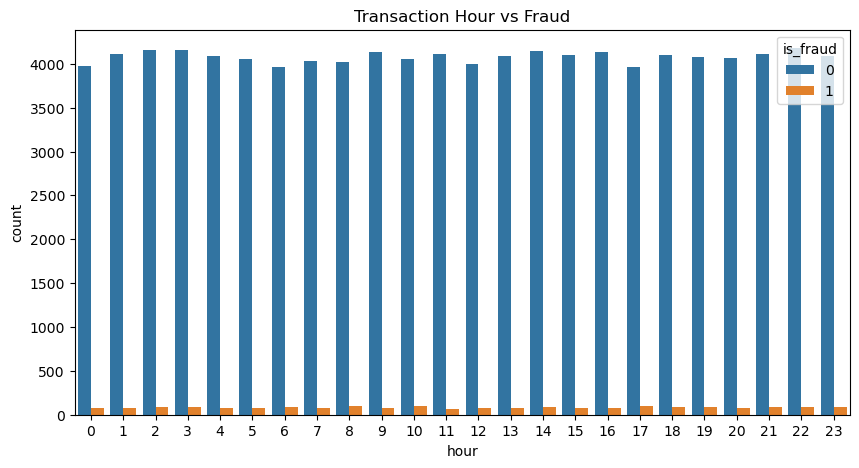

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.countplot(x='hour', hue='is_fraud', data=df)
plt.title("Transaction Hour vs Fraud")
plt.show()


##### 1.Higher fraud frequency during 12 AM – 5 AM
##### 2.Compare fraud ratio per hour

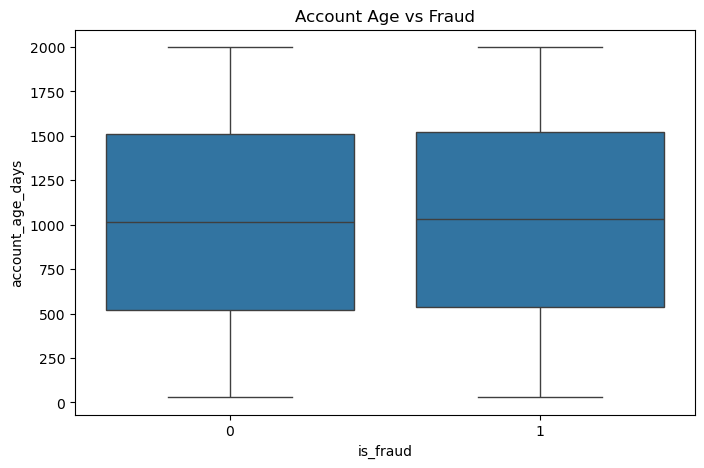

In [10]:
# Account Age Days vs Fraud
plt.figure(figsize=(8,5))
sns.boxplot(x='is_fraud', y='account_age_days', data=df)
plt.title("Account Age vs Fraud")
plt.show()

##### 1.Fraud accounts usually have lower account_age_days
##### 2.New accounts = high risk

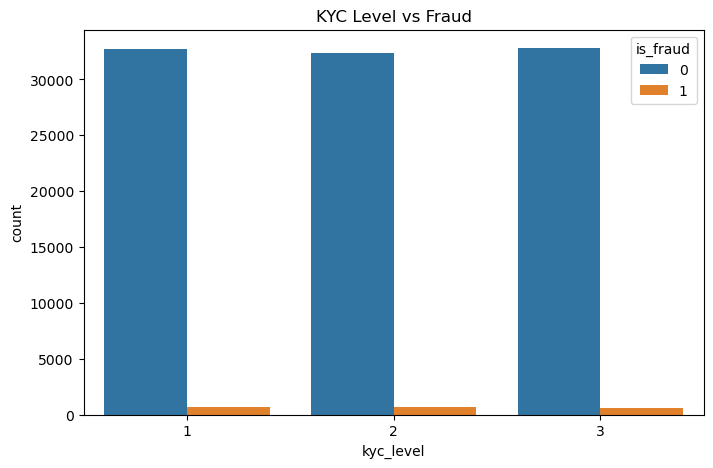

In [11]:
# KYC Level vs Fraud
plt.figure(figsize=(8,5))
sns.countplot(x='kyc_level', hue='is_fraud', data=df)
plt.title("KYC Level vs Fraud")
plt.show()


##### Low KYC level shows higher fraud ratio

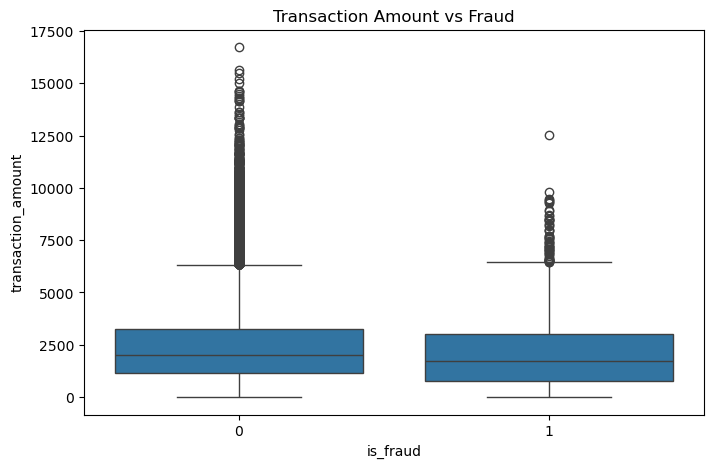

In [12]:
# Transaction Amount vs Fraud
plt.figure(figsize=(8,5))
sns.boxplot(x='is_fraud', y='transaction_amount', data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()

##### Fraud median amount higher
##### Extreme outliers

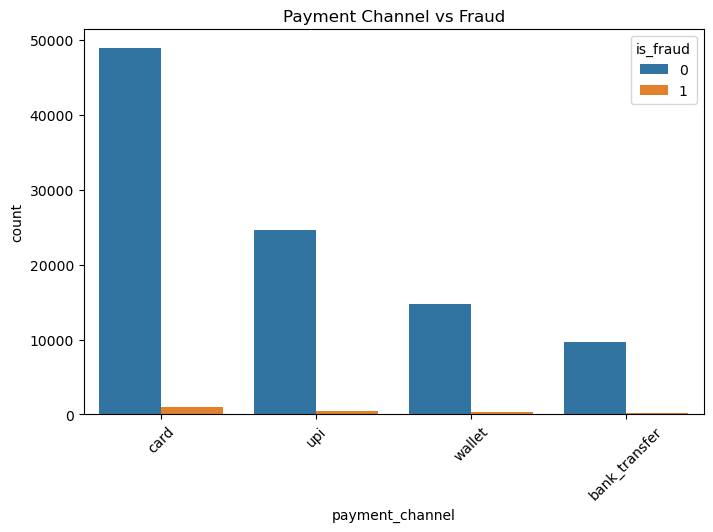

In [13]:
# Payment Channel vs Fraud
plt.figure(figsize=(8,5))
sns.countplot(x='payment_channel', hue='is_fraud', data=df)
plt.xticks(rotation=45)
plt.title("Payment Channel vs Fraud")
plt.show()


##### Card channels may have higher fraud ratio

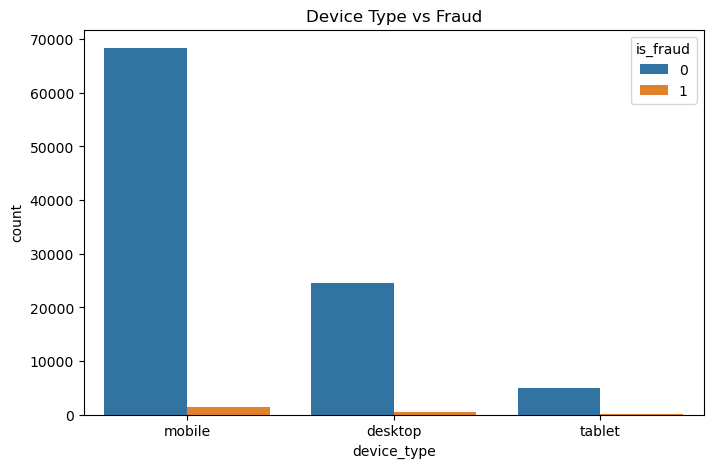

In [14]:
# Device Type vs Fraud
plt.figure(figsize=(8,5))
sns.countplot(x='device_type', hue='is_fraud', data=df)
plt.title("Device Type vs Fraud")
plt.show()

##### Higher fraud in specific device type

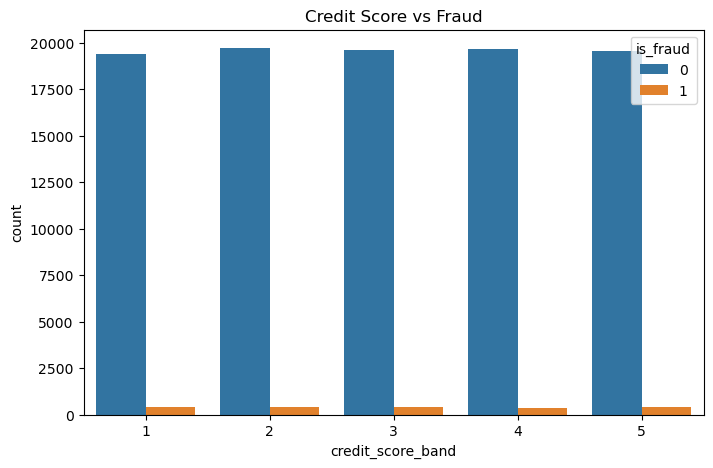

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='credit_score_band', hue='is_fraud', data=df)
plt.title("Credit Score vs Fraud")
plt.show()

<Axes: >

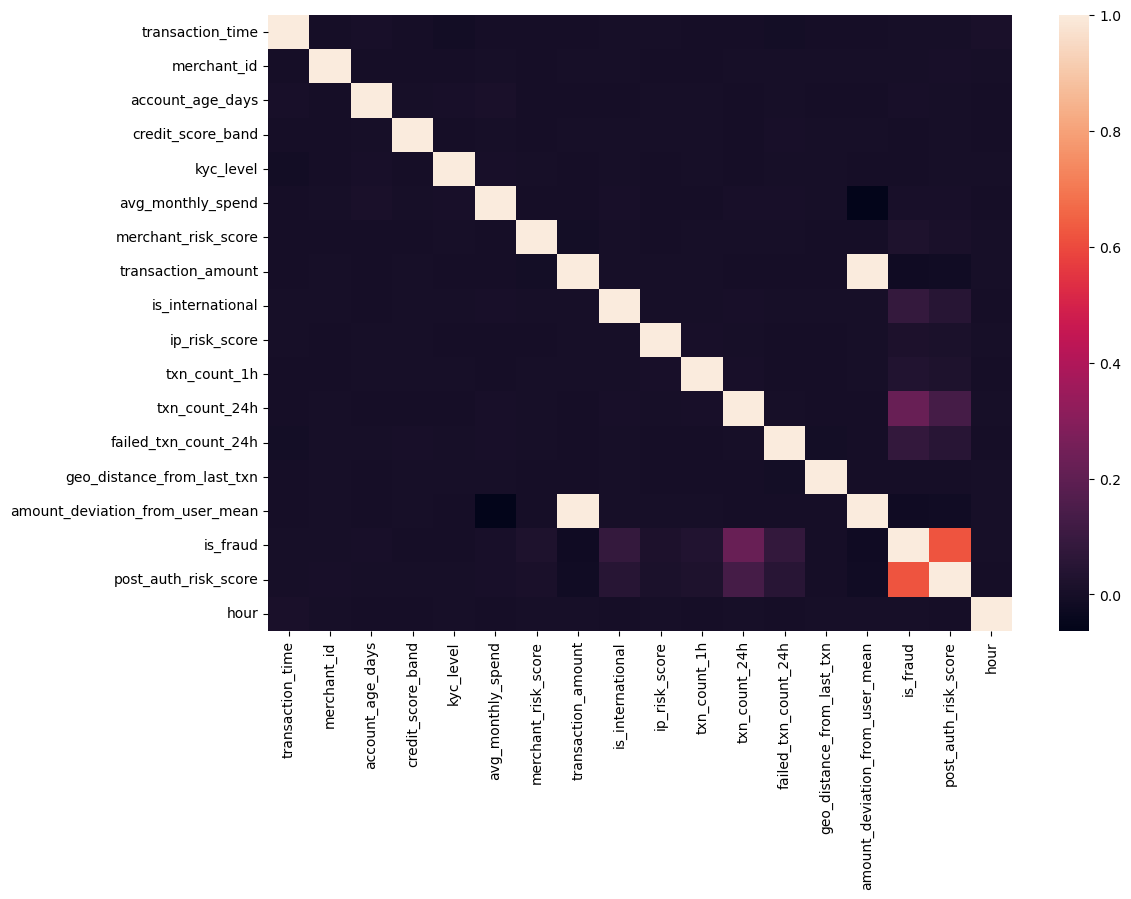

In [17]:
Corelation = df.drop(["payment_channel", "device_type"], axis=1).corr()
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
sns.heatmap(Corelation)

#### feature engineering

In [70]:
df.head()

,transaction_id,transaction_time,customer_id,merchant_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,...,device_type,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,post_auth_risk_score
0,305461,2023-10-01 00:02:41.559131982,11453,7397,1417,4,2,7549.746993,0.056340,1783.564199,...,mobile,0,0.417366,1,2,0,54.226534,1531.905966,0,0.358507
1,341279,2023-10-01 00:06:25.507380194,28021,97,830,2,2,2766.322082,0.736960,7038.755549,...,mobile,0,0.272247,1,3,1,60.728405,6946.544813,0,0.065886
2,344364,2023-10-01 00:07:50.846454903,2269,2796,1651,2,3,3988.151593,0.454618,663.057016,...,mobile,0,0.446442,3,3,0,102.171038,530.118629,0,0.026225
3,84227,2023-10-01 00:17:11.834872052,32373,787,1207,1,2,5472.122178,0.417973,1665.509484,...,desktop,0,0.308703,2,3,0,10.146806,1483.105412,0,0.201940
4,187825,2023-10-01 00:19:50.841780964,13548,4439,1926,5,2,1758.784635,0.535169,1524.306346,...,mobile,1,0.305401,2,1,1,18.328551,1465.680191,0,0.234395


In [78]:
df["transaction_time"] = pd.to_datetime(df["transaction_time"])

df["hour"] = df["transaction_time"].dt.hour
df["day_of_week"] = df["transaction_time"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].apply(lambda x: 1 if x >= 5 else 0)

df.drop("transaction_time", axis=1, inplace=True)

In [79]:
df["txn_velocity_ratio"] = df["txn_count_1h"] / (df["txn_count_24h"] + 1)

In [80]:
df["failed_txn_ratio"] = df["failed_txn_count_24h"] / (df["txn_count_24h"] + 1)

In [81]:
df["amount_risk_score"] = df["transaction_amount"] * df["amount_deviation_from_user_mean"]

In [82]:
df["geo_risk"] = df["geo_distance_from_last_txn"] * df["is_international"]

In [83]:
df.columns

Index(['transaction_id', 'customer_id', 'merchant_id', 'account_age_days',
       'credit_score_band', 'kyc_level', 'avg_monthly_spend',
       'merchant_risk_score', 'transaction_amount', 'payment_channel',
       'device_type', 'is_international', 'ip_risk_score', 'txn_count_1h',
       'txn_count_24h', 'failed_txn_count_24h', 'geo_distance_from_last_txn',
       'amount_deviation_from_user_mean', 'is_fraud', 'post_auth_risk_score',
       'hour', 'day_of_week', 'is_weekend', 'txn_velocity_ratio',
       'failed_txn_ratio', 'amount_risk_score', 'geo_risk'],
      dtype='object')

In [84]:
df.drop(
    ['payment_channel','device_type','txn_count_1h','txn_count_24h',
     'failed_txn_count_24h','amount_deviation_from_user_mean',
     'post_auth_risk_score','merchant_id'],
    axis=1,
    inplace=True
)

In [85]:
df.head()

,transaction_id,customer_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,is_international,ip_risk_score,geo_distance_from_last_txn,is_fraud,hour,day_of_week,is_weekend,txn_velocity_ratio,failed_txn_ratio,amount_risk_score,geo_risk
0,305461,11453,1417,4,2,7549.746993,0.056340,1783.564199,0,0.417366,54.226534,0,0,6,1,0.333333,0.00,2.732253e+06,0.000000
1,341279,28021,830,2,2,2766.322082,0.736960,7038.755549,0,0.272247,60.728405,0,0,6,1,0.250000,0.25,4.889503e+07,0.000000
2,344364,2269,1651,2,3,3988.151593,0.454618,663.057016,0,0.446442,102.171038,0,0,6,1,0.750000,0.00,3.514989e+05,0.000000
3,84227,32373,1207,1,2,5472.122178,0.417973,1665.509484,0,0.308703,10.146806,0,0,6,1,0.500000,0.00,2.470126e+06,0.000000
4,187825,13548,1926,5,2,1758.784635,0.535169,1524.306346,1,0.305401,18.328551,0,0,6,1,1.000000,0.50,2.234146e+06,18.328551


#### Split the Dataset

In [86]:
from sklearn.model_selection import train_test_split

X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [87]:
new_data = X_test.iloc[[0]]
new_data

,transaction_id,customer_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,is_international,ip_risk_score,geo_distance_from_last_txn,hour,day_of_week,is_weekend,txn_velocity_ratio,failed_txn_ratio,amount_risk_score,geo_risk
11676,18851,29735,1305,5,3,4104.955108,0.085572,2450.47347,0,0.084862,21.706645,17,2,0,0.333333,0.0,5.669517e+06,0.0


In [88]:
y_test.loc[11676]

np.int64(0)

In [89]:
# Balance the Imbalance dataset
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

In [90]:
y_train.value_counts()

is_fraud
0    78323
1    78323
Name: count, dtype: int64

<Axes: xlabel='transaction_id', ylabel='customer_id'>

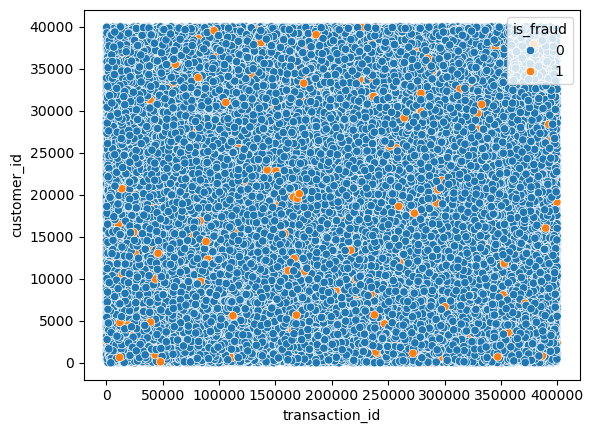

In [91]:
X.iloc[:, 0] 
sns.scatterplot(x=X.iloc[:, 0], y=X.iloc[:, 1], hue=y)

#### LogisticRegression

In [92]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)


from sklearn.metrics import classification_report, roc_auc_score,accuracy_score

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

0.5924016418059865
              precision    recall  f1-score   support

           0       0.98      0.59      0.74     19581
           1       0.03      0.54      0.05       397

    accuracy                           0.59     19978
   macro avg       0.51      0.57      0.40     19978
weighted avg       0.97      0.59      0.73     19978

ROC AUC: 0.5701483870461483


C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [93]:
# Trained Model in new data
y_pred_new_data_log  = model.predict(new_data)
y_pred_new_data_log

array([0])

#### RandomForestClassifier

In [94]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

from sklearn.metrics import classification_report, roc_auc_score,accuracy_score

y_pred = rf.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))


0.9792772049254179
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     19581
           1       0.44      0.16      0.24       397

    accuracy                           0.98     19978
   macro avg       0.71      0.58      0.61     19978
weighted avg       0.97      0.98      0.97     19978

ROC AUC: 0.7250408012599475


In [95]:
y_pred_new_data_rf  = model.predict(new_data)
y_pred_new_data_rf

array([0])

#### XGBClassifier

In [96]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train, y_train)


from sklearn.metrics import classification_report, roc_auc_score,accuracy_score

y_pred = xgb.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:,1]))


0.9781259385323856
              precision    recall  f1-score   support

           0       0.98      0.99      0.99     19581
           1       0.40      0.19      0.26       397

    accuracy                           0.98     19978
   macro avg       0.69      0.59      0.62     19978
weighted avg       0.97      0.98      0.97     19978

ROC AUC: 0.7332081927463483


In [97]:
y_pred_new_data_xg  = model.predict(new_data)
y_pred_new_data_xg

array([0])